# Inference and Evaluation of Pretrained E. coli FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on E. coli iML1515 metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

This model is meant to be used with experimental data.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HFTOKEN")

In [2]:
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from train_flux_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [3]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [4]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [5]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        input_token_indices,          # list[int] or 1D tensor[int64]
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
    ):
        super().__init__()
        if vocab_size is None:
            raise ValueError("vocab_size must be provided explicitly.")
        self.vocab_size = int(vocab_size)
        self.d_model = d_model

        idx = torch.as_tensor(input_token_indices, dtype=torch.long)
        if idx.ndim != 1:
            raise ValueError("input_token_indices must be 1D.")
        if (idx < 0).any() or (idx >= self.vocab_size).any():
            raise ValueError("input_token_indices contains out-of-range indices.")
        # Register as buffer so it moves with .to(device)
        self.register_buffer("input_token_indices", idx, persistent=True)

        self.input_embedding = nn.Embedding(self.vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        c: (batch, vocab_size, 1)
        output_subset: 1D tensor of token indices to train on (typically excludes injected tokens)
        """
        batch_size = c.size(0)

        always = self.input_token_indices  # (n_injected,)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            output_subset = output_subset.to(c.device).long()
            selected_indices = torch.unique(torch.cat([always, output_subset]), sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)      # (B, S)
        x = self.input_embedding(y)                                    # (B, S, d_model)

        c_subset = c[:, selected_indices, :]                           # (B, S, 1)
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size(1), len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices

        return c_subset_all_layers, selected_indices

In [6]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        input_token_indices=config['input_token_indices'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [7]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    import os
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [8]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    import os
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    if display_label.endswith('_flux'):
        display_label = display_label[:-5]
    if display_label.upper().startswith('BIOMASS'):
        display_label = 'Biomass iML1515'

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    if str(label).upper().startswith('BIOMASS'):
        axs[0, 1].set_ylim(-0.05, 0.05)
    else:
        res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
        if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
            res_abs_max = 1.0
        axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [9]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs,
    flux_name: str,
    save_path=None,
    batch_size: int = 16,
    device: str | torch.device | None = None,
):
    """
    Plot diagnostics for a token name in `outputs`.

    Assumptions:
      - outputs defines token order, len(outputs) == model.vocab_size
      - X_test is (N, vocab_size) and contains medium constraints only at injected token indices
      - y_test is (N, vocab_size) and contains realized fluxes for all tokens
      - model forward returns (preds_all_layers, selected_indices)
        where preds_all_layers is (B, S, n_layers) and selected_indices are token indices
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    model = model.to(device).eval()

    # Basic sanity checks
    if len(outputs) != getattr(model, "vocab_size", None):
        raise ValueError(f"len(outputs)={len(outputs)} does not match model.vocab_size={model.vocab_size}")

    if X_test.ndim != 2 or y_test.ndim != 2:
        raise ValueError(f"Expected X_test and y_test as 2D tensors (N, vocab_size). Got {X_test.shape=}, {y_test.shape=}")

    if X_test.shape[1] != model.vocab_size or y_test.shape[1] != model.vocab_size:
        raise ValueError(
            f"Feature dim mismatch. Expected vocab_size={model.vocab_size}. "
            f"Got X_test.shape[1]={X_test.shape[1]}, y_test.shape[1]={y_test.shape[1]}"
        )

    if flux_name not in outputs:
        raise ValueError(f"Flux '{flux_name}' not in outputs (len={len(outputs)}).")

    token_idx = outputs.index(flux_name)

    pred_vals = []
    true_vals = []
    pos = None
    use_amp = device.type == "cuda"

    # Diagnostics use full-context forward (output_subset=None), which can be memory-heavy on CUDA.
    # Use a conservative default batch size on GPU unless user explicitly asks for <=2.
    if device.type == "cuda" and batch_size > 2:
        batch_size = 2

    with torch.inference_mode():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i + batch_size].to(device)          # [B, vocab_size]
            yb_true = y_test[i:i + batch_size]                # [B, vocab_size]
            c = xb.unsqueeze(-1)                              # [B, vocab_size, 1]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model(c, output_subset=None)
            else:
                preds_all_layers, selected_indices = model(c, output_subset=None)

            # Map token_idx -> its position inside selected_indices (once is enough)
            if pos is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                hit = np.where(selected_indices_np == token_idx)[0]
                if hit.size == 0:
                    raise RuntimeError(
                        f"Token index {token_idx} for '{flux_name}' was not produced by the model forward pass. "
                        "This should not happen when output_subset=None."
                    )
                pos = int(hit[0])

            yb_pred_flux = preds_all_layers[:, pos, -1].detach().cpu().numpy()
            yb_true_flux = yb_true[:, token_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.type == "cuda":
                torch.cuda.empty_cache()

    y_pred = np.concatenate(pred_vals, axis=0)
    y_true = np.concatenate(true_vals, axis=0)

    # Is this an injected (medium constraint) token slot?
    injected = False
    if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
        injected = bool((model.input_token_indices.detach().cpu() == token_idx).any().item())

    print(f"{flux_name} token index: {token_idx}")
    print(f"injected medium slot: {injected}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    # Per-flux metrics for the currently plotted token
    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = float("nan")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"R2: {r2:.4f}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )

### Load model

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
model_name = "iML1515_MINN_500k_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/iML1515_MINN_500k_d256_h8_l3_ff1024/iML1515_MINN_500k_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,069,729

Data information:
Dataset: ./data/iML1515_MINN_training_data_500k_samples.csv
Training samples: 399916
Test samples: 99980


### Load data

In [12]:
# Load data using the same function as during training
#set_seed()

DATA_PATH = f"./data/iML1515_MINN_test_data_49982_samples.csv"

#X, y, inputs, outputs, input_token_indices, out_indices = load_data(data_info['dataset'])
X, y, inputs, outputs, input_token_indices, out_indices = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

model.eval()


Loaded data with 49982 samples from ./data/iML1515_MINN_test_data_49982_samples.csv
Extracted input columns count:  27
Extracted output columns count: 2712
Medium constraints are injected into these token indices (in outputs order):
[180, 1525, 106, 40, 45, 92, 104, 164, 304, 621, 700, 859, 913, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 1981, 86, 934, 2243, 2320, 633]
Training samples: 39985
Test samples: 9997


FluxTransformer(
  (input_embedding): Embedding(2712, 256)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((257,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=257, out_features=1024, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=1024, out_features=257, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

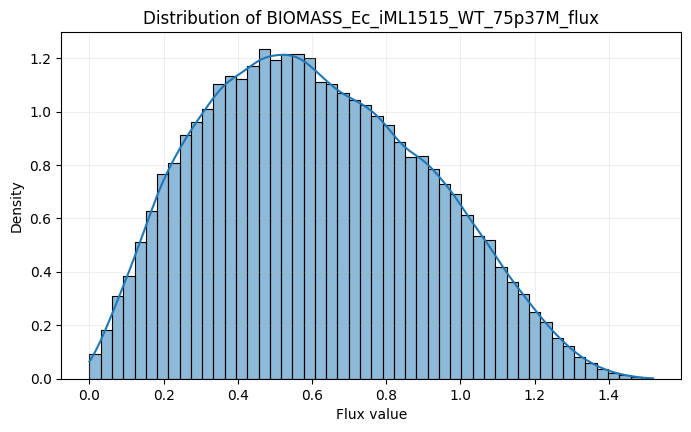

In [13]:
def plot_flux_distribution(y, outputs, flux_name, bins=50, figsize=(8, 4.5)):
    """Plot the distribution of a selected output flux from target tensor y."""
    if flux_name not in outputs:
        raise ValueError(f"{flux_name} not found in outputs.")
    flux_idx = outputs.index(flux_name)
    flux_values = y[:, flux_idx]
    if isinstance(flux_values, torch.Tensor):
        flux_values = flux_values.detach().cpu().numpy()
    else:
        flux_values = np.asarray(flux_values)

    plt.figure(figsize=figsize)
    sns.histplot(flux_values, bins=bins, kde=True, stat="density", color="tab:blue")
    plt.title(f"Distribution of {flux_name}")
    plt.xlabel("Flux value")
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.show()

plot_flux_distribution(y, outputs, "BIOMASS_Ec_iML1515_WT_75p37M_flux")

### Plot Results

In [14]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

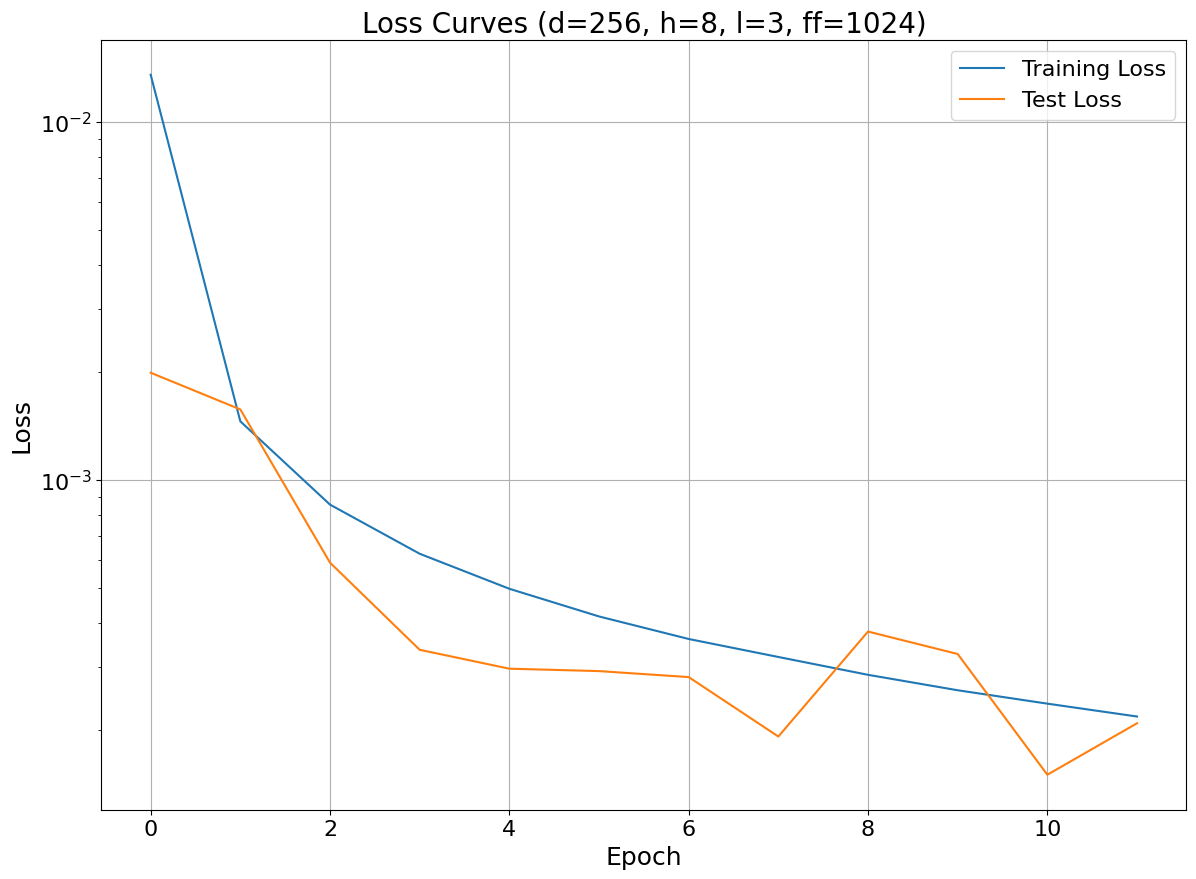

In [15]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

BIOMASS_Ec_iML1515_WT_75p37M_flux:
------------------------------------------------------------
BIOMASS_Ec_iML1515_WT_75p37M_flux token index: 2669
injected medium slot: False
y_true range: 0.0033479833509773016 to 1.5196515321731567
y_pred range: 0.011320769786834717 to 1.5010480880737305
R2: 0.9997
MAE: 0.003740
RMSE: 0.004859


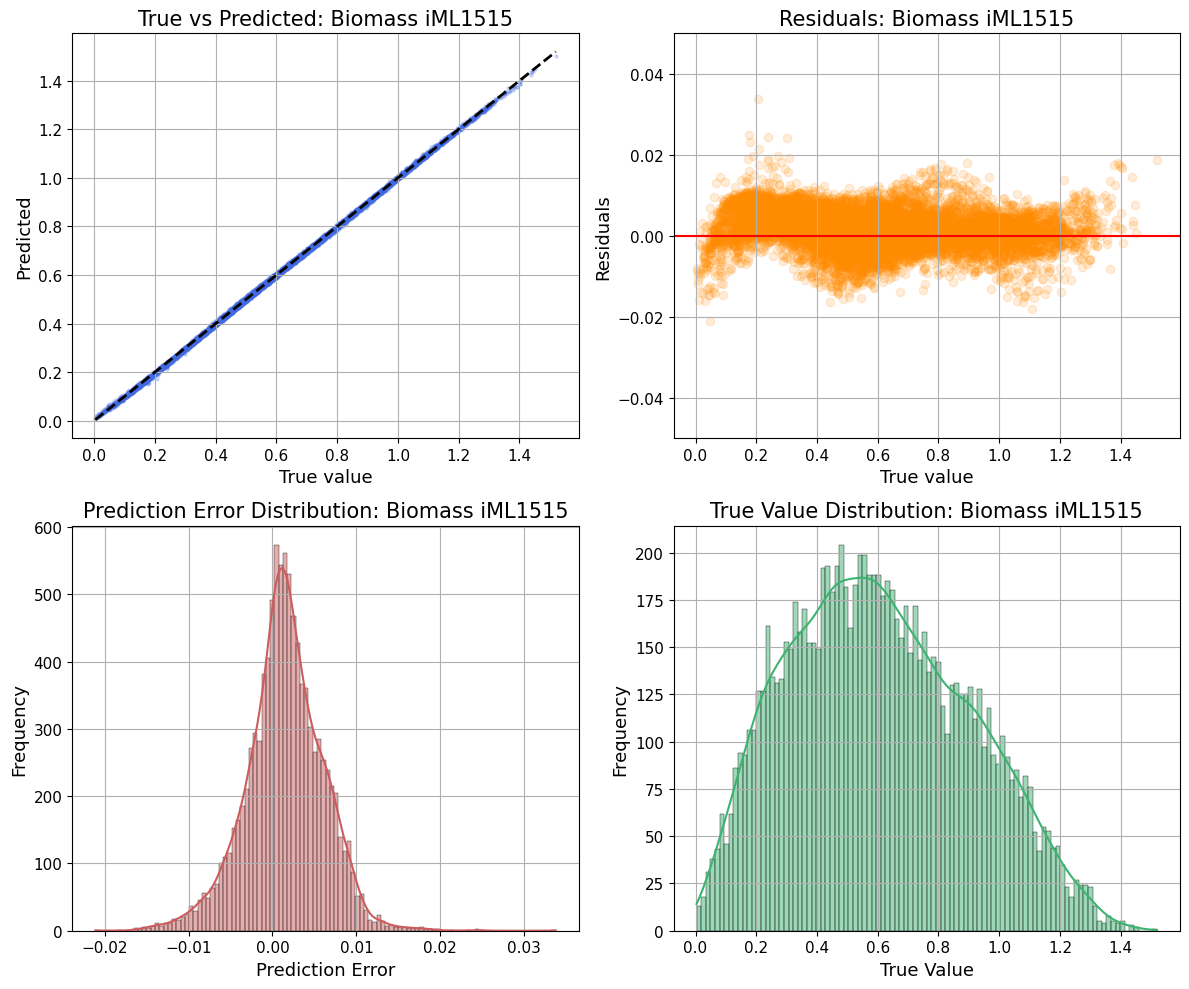

In [16]:
diagnostics_to_plot = ['BIOMASS_Ec_iML1515_WT_75p37M_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=save_path)

GLUDy_flux:
------------------------------------------------------------
GLUDy_flux token index: 1404
injected medium slot: False
y_true range: -12.721437454223633 to -0.02783106453716755
y_pred range: -12.542888641357422 to -0.07740616798400879
R2: 0.9998
MAE: 0.025948
RMSE: 0.031672


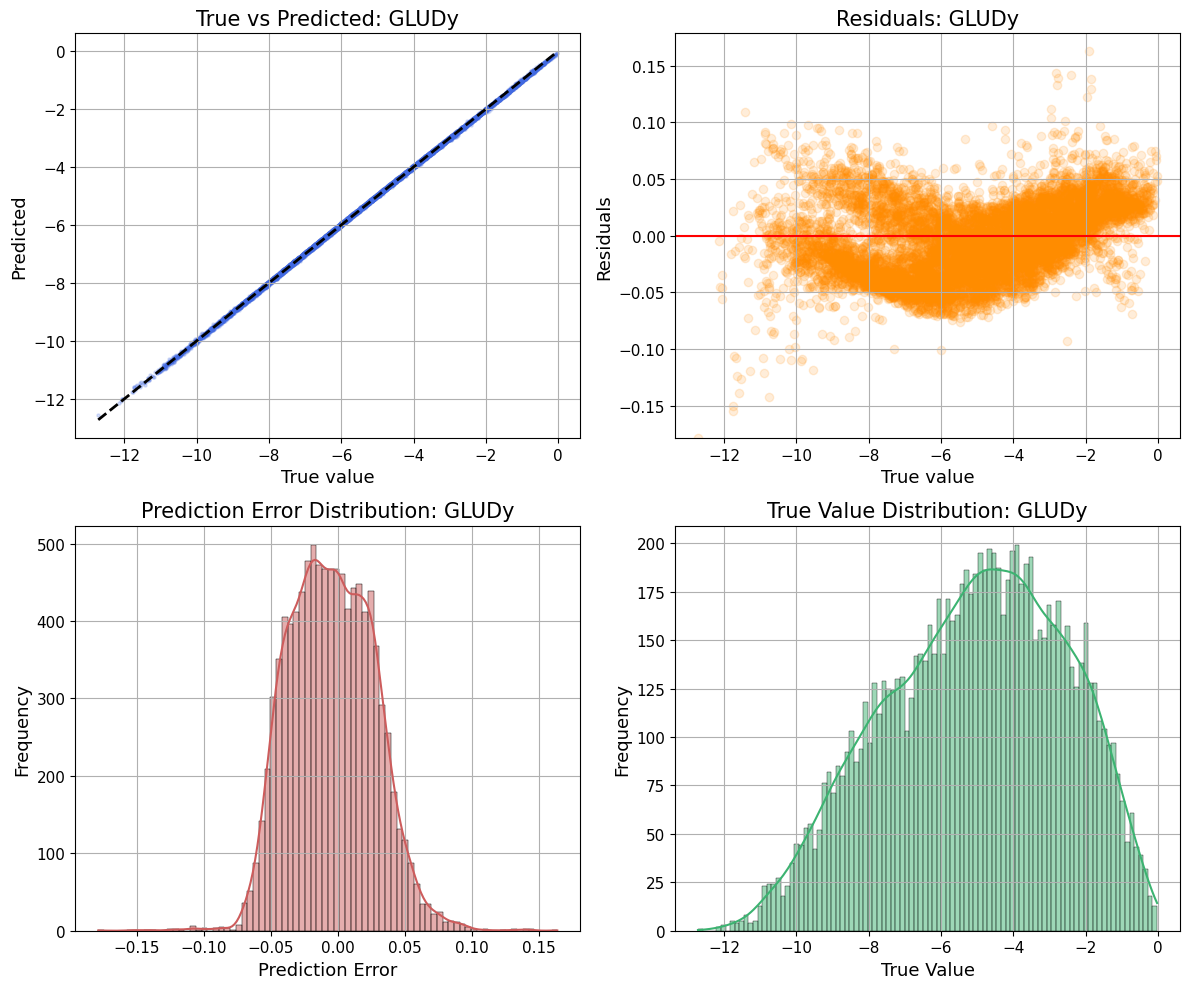

H2Otpp_flux:
------------------------------------------------------------
H2Otpp_flux token index: 1362
injected medium slot: False
y_true range: -86.13911437988281 to 2.170999050140381
y_pred range: -84.72208404541016 to 1.9921255111694336
R2: 0.9998
MAE: 0.231167
RMSE: 0.266625


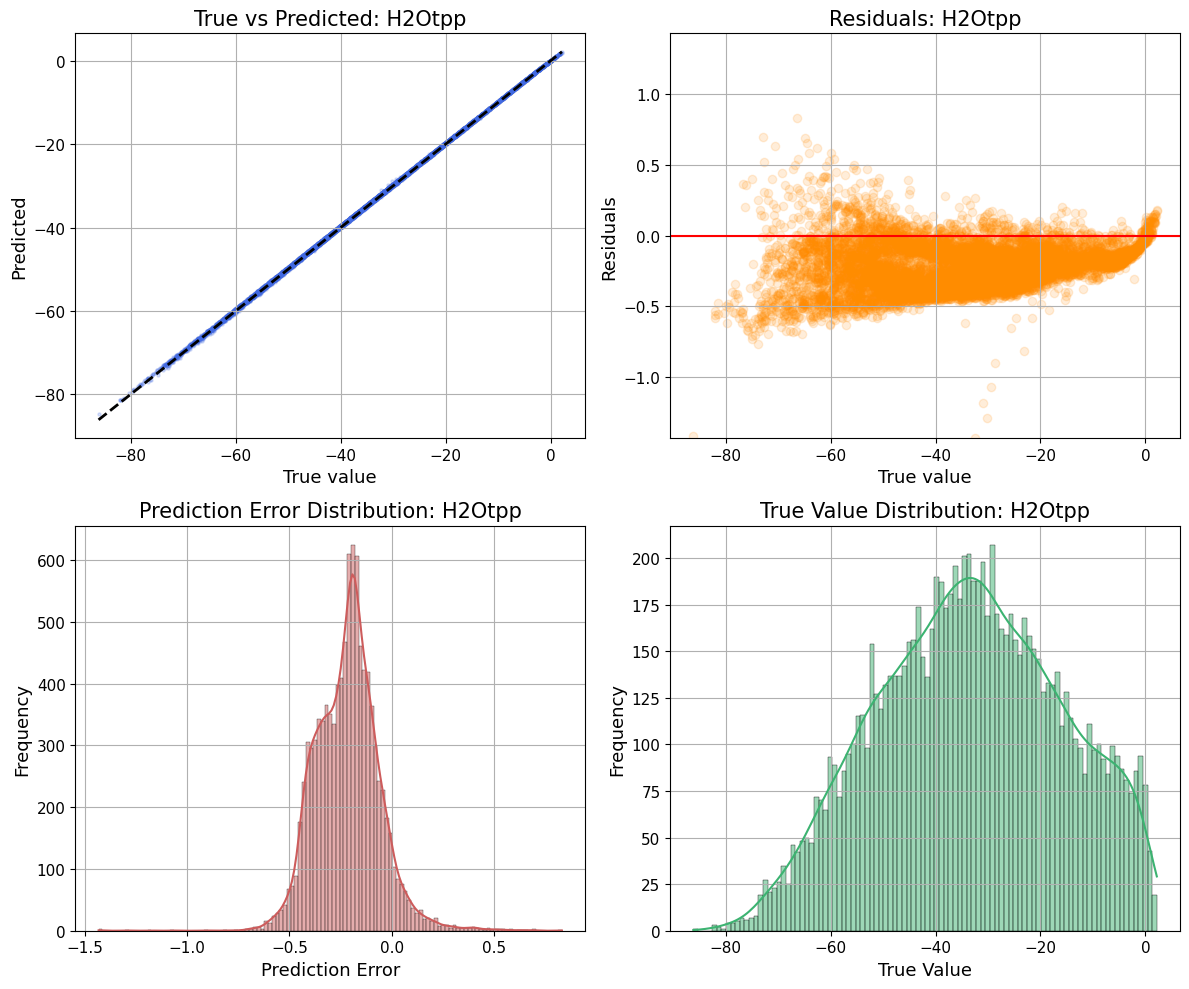

In [17]:
diagnostics_to_plot = ['GLUDy_flux', 'H2Otpp_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)

In [18]:
# Overall model metrics across all output fluxes (flattened)
def _compute_overall_metrics(model_ref, X_ref, y_ref, outputs_ref, device_ref, batch_size_ref):
    model_eval = model_ref.to(device_ref).eval()
    V = len(outputs_ref)

    if X_ref.shape[1] != V or y_ref.shape[1] != V:
        raise ValueError(
            f"Expected X_test/y_test second dim == len(outputs)={V}, got {X_ref.shape[1]} and {y_ref.shape[1]}"
        )

    pred_batches = []
    true_batches = []
    perm = None
    use_amp = device_ref.type == "cuda"

    with torch.inference_mode():
        for i in range(0, X_ref.shape[0], batch_size_ref):
            xb = X_ref[i:i + batch_size_ref].to(device_ref)
            yb_true = y_ref[i:i + batch_size_ref]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)
            else:
                preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)

            preds_last = preds_all_layers[:, :, -1]  # (B, S)

            if perm is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                selected_indices_np = selected_indices_np.astype(int)

                if selected_indices_np.size != V:
                    raise RuntimeError(f"Model returned {selected_indices_np.size} outputs, expected {V}.")

                inv = np.full(V, -1, dtype=np.int64)
                inv[selected_indices_np] = np.arange(selected_indices_np.size, dtype=np.int64)
                if (inv < 0).any():
                    missing = np.where(inv < 0)[0].tolist()
                    raise RuntimeError(f"Missing output indices in model forward pass: {missing[:10]}")
                perm = torch.as_tensor(inv, device=preds_last.device, dtype=torch.long)

            yb_pred = preds_last.index_select(1, perm).detach().cpu().numpy().astype(np.float32, copy=False)
            pred_batches.append(yb_pred)
            true_batches.append(yb_true.detach().cpu().numpy().astype(np.float32, copy=False))

            del xb, preds_all_layers, preds_last, selected_indices
            if device_ref.type == "cuda":
                torch.cuda.empty_cache()

    y_pred_full = np.concatenate(pred_batches, axis=0)
    y_true_full = np.concatenate(true_batches, axis=0)

    overall_r2 = r2_score(y_true_full.ravel(), y_pred_full.ravel())
    overall_mae = mean_absolute_error(y_true_full.ravel(), y_pred_full.ravel())
    overall_rmse = root_mean_squared_error(y_true_full.ravel(), y_pred_full.ravel())
    return overall_r2, overall_mae, overall_rmse

original_device = next(model.parameters()).device
preferred_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if preferred_device.type == "cuda":
    batch_size_metrics = 2
else:
    batch_size_metrics = 32

used_device = preferred_device
try:
    overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
        model, X_test, y_test, outputs, preferred_device, batch_size_metrics
    )
except RuntimeError as e:
    if preferred_device.type == "cuda" and "out of memory" in str(e).lower():
        print("CUDA OOM during overall metrics; falling back to CPU...")
        torch.cuda.empty_cache()
        used_device = torch.device("cpu")
        overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
            model, X_test, y_test, outputs, used_device, 32
        )
    else:
        raise
finally:
    model.to(original_device)

print("Overall model metrics (all fluxes, flattened):")
print(f"Device used: {used_device}")
print(f"R2:   {overall_r2:.4f}")
print(f"MAE:  {overall_mae:.6f}")
print(f"RMSE: {overall_rmse:.6f}")

Overall model metrics (all fluxes, flattened):
Device used: cuda
R2:   0.9999
MAE:  0.003760
RMSE: 0.020569


### MINN


In [29]:
from pathlib import Path


def _minn_to_flux_token(rxn_name: str, outputs_vocab):
    """Map MINN reaction naming to FluxTransformer token names (+ sign conversion for *_rev)."""
    if rxn_name.startswith("R_BIOMASS"):
        if "BIOMASS_Ec_iML1515_WT_75p37M_flux" in outputs_vocab:
            return "BIOMASS_Ec_iML1515_WT_75p37M_flux", 1.0
        if "BIOMASS_Ec_iML1515_core_75p37M_flux" in outputs_vocab:
            return "BIOMASS_Ec_iML1515_core_75p37M_flux", 1.0

    base = rxn_name
    if base.startswith("R_"):
        base = base[2:]

    sign = 1.0
    if base.endswith("_fwd"):
        base = base[:-4]
    elif base.endswith("_rev"):
        base = base[:-4]
        sign = -1.0

    tok = f"{base}_flux"
    if tok in outputs_vocab:
        return tok, sign
    return None, None


# ----- MINN-reservoir-compatible settings -----
MINN_DATA_DIR = "./MINN_data"
MINN_FLUXOMICS_FILE = "fluxomics_iAF1260_reduced_split_fit.csv"

# 2 input fluxes (same as MINN dataset config)
MINN_INPUT_FLUX_COLS = ["R_EX_glc__D_e_rev", "R_EX_o2_e_rev"]

# 5 fluxes predicted by the front MLP (MINN reservoir style)
MINN_PREDICTED_5_SOURCE = [
    "R_EX_glc__D_e_rev",
    "R_EX_o2_e_rev",
    "R_EX_co2_e_fwd",
    "R_EX_etoh_e",
    "R_EX_ac_e",
]

# base_exchanges from generate_ecoli_iML1515_MINN_data.py
BASE_EXCHANGES = [
    "EX_pi_e",
    "EX_co2_e",
    "EX_h_e",
    "EX_mn2_e",
    "EX_fe2_e",
    "EX_zn2_e",
    "EX_mg2_e",
    "EX_ca2_e",
    "EX_ni2_e",
    "EX_cu2_e",
    "EX_cobalt2_e",
    "EX_h2o_e",
    "EX_mobd_e",
    "EX_so4_e",
    "EX_nh4_e",
    "EX_k_e",
    "EX_na1_e",
    "EX_cl_e",
    "EX_o2_e",
    "EX_fe3_e",
    "EX_sel_e",
    "EX_tungs_e",
    "EX_slnt_e",
    "EX_cbl1_e",
]
DEFAULT_BASE_EXCHANGE_RATE = 50.0


def load_minn_omics_for_reservoir(data_dir: str, outputs_vocab):
    """
    Load MINN-style input (omics + 2 fluxes) and build 5-target labels
    mapped into FluxTransformer token space.
    """
    data_dir_p = Path(data_dir)
    transcript_path = data_dir_p / "transcriptomics.csv"
    proteomics_path = data_dir_p / "proteomics.csv"
    fluxomics_path = data_dir_p / MINN_FLUXOMICS_FILE

    if not transcript_path.exists() or not proteomics_path.exists() or not fluxomics_path.exists():
        raise FileNotFoundError(
            f"Expected MINN files in {data_dir}: transcriptomics.csv, proteomics.csv, {MINN_FLUXOMICS_FILE}"
        )

    tr = pd.read_csv(transcript_path)
    pr = pd.read_csv(proteomics_path)
    fl = pd.read_csv(fluxomics_path)

    # MINN-style merge
    x_df = tr.merge(pr, on="experiment", how="left")

    missing_input = [c for c in MINN_INPUT_FLUX_COLS if c not in fl.columns]
    if missing_input:
        raise ValueError(f"Missing MINN input flux columns: {missing_input}")

    x_df = x_df.merge(fl[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
    x_df = x_df[x_df["experiment"].isin(fl["experiment"])].reset_index(drop=True)

    fl_idx = fl.set_index("experiment")

    mapped = []  # (source_col, token_name, token_idx, sign)
    for source_col in MINN_PREDICTED_5_SOURCE:
        if source_col not in fl.columns:
            raise ValueError(f"Missing target source column in fluxomics file: {source_col}")
        tok, sign = _minn_to_flux_token(source_col, outputs_vocab)
        if tok is None:
            raise RuntimeError(f"Could not map {source_col} into FluxTransformer token vocabulary")
        mapped.append((source_col, tok, outputs_vocab.index(tok), sign))

    # Inputs
    x_features = [c for c in x_df.columns if c != "experiment"]
    X_np = x_df[x_features].to_numpy(dtype=np.float32)

    # Targets (5), mapped with sign
    experiments = x_df["experiment"].tolist()
    y_rows = []
    for exp in experiments:
        row = []
        for src, _tok, _idx, sign in mapped:
            row.append(float(fl_idx.at[exp, src]) * sign)
        y_rows.append(row)

    y_np = np.asarray(y_rows, dtype=np.float32)

    target_token_names = [tok for _src, tok, _idx, _sign in mapped]
    target_token_indices = [idx for _src, _tok, idx, _sign in mapped]

    return X_np, y_np, x_features, target_token_names, target_token_indices, mapped


(
    X_minn_np,
    y_minn_np,
    minn_feature_names,
    minn_target_token_names,
    minn_target_indices,
    minn_mapped_sources,
) = load_minn_omics_for_reservoir(
    data_dir=MINN_DATA_DIR,
    outputs_vocab=outputs,
)

minn_target_indices_t = torch.tensor(minn_target_indices, dtype=torch.long, device=device)
# Signs used in MINN source naming (*_rev -> -1). Needed to recover positive constraint magnitudes for front-MLP supervision.
minn_target_signs = np.asarray([float(sign) for _src, _tok, _idx, sign in minn_mapped_sources], dtype=np.float32)
minn_target_signs_t = torch.tensor(minn_target_signs, dtype=torch.float32, device=device)

# Build fixed base exchange constraints in FluxTransformer token space
# Rules:
# - predicted 5 are provided by front MLP
# - remaining base_exchanges are fixed at DEFAULT_BASE_EXCHANGE_RATE
# - all other inputs are zero
predicted_token_set = set(minn_target_token_names)
fixed_base_token_values = {}
for ex in BASE_EXCHANGES:
    tok = f"{ex}_flux"
    if tok in outputs and tok not in predicted_token_set:
        fixed_base_token_values[tok] = float(DEFAULT_BASE_EXCHANGE_RATE)


class FrozenFluxTransformerWithMLP(nn.Module):
    """
    MINN-reservoir-compatible wrapper for FluxTransformer:
    - Front MLP predicts ONLY 5 exchange channels
    - Full FluxTransformer input vector is assembled as:
        predicted 5 + fixed base_exchanges + zeros elsewhere
    - Frozen pretrained FluxTransformer
    """
    def __init__(
        self,
        flux_transformer: nn.Module,
        input_dim: int,
        predicted_token_names,
        fixed_base_token_values,
        hidden_dim: int = 512,
        drop_rate: float = 0.25,
    ):
        super().__init__()
        self.frozen_flux_transformer = flux_transformer
        self.vocab_size = int(self.frozen_flux_transformer.vocab_size)

        self.predicted_token_names = list(predicted_token_names)
        self.fixed_base_token_values = dict(fixed_base_token_values)

        token_to_idx = {tok: i for i, tok in enumerate(outputs)}
        pred_indices = []
        for tok in self.predicted_token_names:
            if tok not in token_to_idx:
                raise ValueError(f"Predicted token not found in outputs vocab: {tok}")
            pred_indices.append(token_to_idx[tok])

        fixed_names = []
        fixed_vals = []
        for tok, val in self.fixed_base_token_values.items():
            if tok in token_to_idx:
                fixed_names.append(tok)
                fixed_vals.append(float(val))

        self.register_buffer("predicted_indices", torch.tensor(pred_indices, dtype=torch.long), persistent=True)
        self.register_buffer("fixed_indices", torch.tensor([token_to_idx[t] for t in fixed_names], dtype=torch.long), persistent=True)
        self.register_buffer("fixed_values", torch.tensor(fixed_vals, dtype=torch.float32), persistent=True)

        for p in self.frozen_flux_transformer.parameters():
            p.requires_grad = False
        self.frozen_flux_transformer.eval()

        # Predict exactly 5 channels
        self.front_mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(hidden_dim, len(self.predicted_token_names)),
        )

    def train(self, mode: bool = True):
        super().train(mode)
        self.frozen_flux_transformer.eval()
        return self

    def build_full_input_vector(self, x):
        # x: [B, n_features]
        pred_raw = self.front_mlp(x)  # [B,5]
        pred_vals = F.softplus(pred_raw)  # keep constraints non-negative

        B = x.size(0)
        c0 = torch.zeros(B, self.vocab_size, dtype=x.dtype, device=x.device)

        if self.fixed_indices.numel() > 0:
            c0[:, self.fixed_indices] = self.fixed_values.to(dtype=x.dtype, device=x.device).unsqueeze(0)

        c0[:, self.predicted_indices] = pred_vals
        return c0

    def forward(self, x, output_subset=None, return_embedding=False):
        if x.dim() == 3 and x.size(-1) == 1:
            x = x.squeeze(-1)
        c0 = self.build_full_input_vector(x).unsqueeze(-1)
        return self.frozen_flux_transformer(c0, output_subset=output_subset, return_embedding=return_embedding)


# Build model
minn_model = FrozenFluxTransformerWithMLP(
    flux_transformer=model,
    input_dim=X_minn_np.shape[1],
    predicted_token_names=minn_target_token_names,
    fixed_base_token_values=fixed_base_token_values,
    hidden_dim=512,
    drop_rate=0.25,
).to(device)

with torch.no_grad():
    _x2 = torch.tensor(X_minn_np[:2], dtype=torch.float32, device=device)
    _c0_sanity = minn_model.build_full_input_vector(_x2)
    _pred_sanity, _sel_sanity = minn_model(_x2, output_subset=None)

trainable_params = sum(p.numel() for p in minn_model.parameters() if p.requires_grad)
frozen_flux_params = sum(p.numel() for p in minn_model.frozen_flux_transformer.parameters() if not p.requires_grad)

print("Loaded MINN-style omics dataset")
print(f"MINN data dir: {MINN_DATA_DIR}")
print(f"Samples: {X_minn_np.shape[0]}")
print(f"Input features (omics + 2 input fluxes): {X_minn_np.shape[1]}")
print("2 input flux columns:", MINN_INPUT_FLUX_COLS)
print("5 predicted source fluxes:", MINN_PREDICTED_5_SOURCE)
print("Mapped predicted token names:", minn_target_token_names)
print("MINN source -> FluxTransformer token mapping (with sign)")
for src, tok, idx, sign in minn_mapped_sources:
    print(f"  {src:>18} -> {tok:<20} idx={idx:4d} sign={sign:+.0f}")
print(f"Fixed base exchange token count: {len(fixed_base_token_values)} (value={DEFAULT_BASE_EXCHANGE_RATE})")
print(f"Trainable params (front MLP only): {trainable_params:,}")
print(f"Frozen FluxTransformer params:      {frozen_flux_params:,}")
print(f"Sanity c0 shape:                   {tuple(_c0_sanity.shape)}")
print(f"Sanity transformer output shape:   {tuple(_pred_sanity.shape)}")


Loaded MINN-style omics dataset
MINN data dir: ./MINN_data
Samples: 29
Input features (omics + 2 input fluxes): 141
2 input flux columns: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
5 predicted source fluxes: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev', 'R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
Mapped predicted token names: ['EX_glc__D_e_flux', 'EX_o2_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_ac_e_flux']
Fixed base exchange token count: 22 (value=50.0)
Trainable params (front MLP only): 75,269
Frozen FluxTransformer params:      3,069,729
Sanity c0 shape:                   (2, 2712)
Sanity transformer output shape:   (2, 2712, 3)


In [30]:
# Assertions: token/reaction mapping and sign conventions for MINN -> iML1515 integration

import xml.etree.ElementTree as ET
from pathlib import Path

# 1) Required predicted tokens must exist in outputs vocab
required_pred_tokens = [
    "EX_glc__D_e_flux",
    "EX_o2_e_flux",
    "EX_co2_e_flux",
    "EX_etoh_e_flux",
    "EX_ac_e_flux",
]

missing_pred_tokens = [t for t in required_pred_tokens if t not in outputs]
assert not missing_pred_tokens, (
    "Missing required predicted tokens in outputs vocab: "
    + ", ".join(missing_pred_tokens)
)

# 2) Base exchange tokens must exist in outputs vocab
base_tokens = [f"{ex}_flux" for ex in BASE_EXCHANGES]
missing_base_tokens = [t for t in base_tokens if t not in outputs]
assert not missing_base_tokens, (
    "Missing base exchange tokens in outputs vocab: "
    + ", ".join(missing_base_tokens)
)

# 3) pFBA-constrained reactions must exist in iML1515 model
model_path = Path("./models/iML1515.xml")
assert model_path.exists(), f"SBML model not found: {model_path}"

ns = {"sbml": "http://www.sbml.org/sbml/level3/version1/core"}
root = ET.parse(model_path).getroot()
rxn_ids = [r.attrib.get("id", "") for r in root.findall('.//sbml:listOfReactions/sbml:reaction', ns)]
rxn_ids_norm = {(rid[2:] if rid.startswith("R_") else rid) for rid in rxn_ids}

required_pfba_rxns = ["EX_glc__D_e", "EX_o2_e", "EX_co2_e", "EX_etoh_e", "EX_ac_e"]
missing_rxns = [r for r in required_pfba_rxns if r not in rxn_ids_norm]
assert not missing_rxns, "Missing required pFBA reactions in iML1515 model: " + ", ".join(missing_rxns)

# 4) MINN split sign convention sanity: *_rev and *_fwd source columns should be nonnegative magnitudes
fluxomics_path = Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE
assert fluxomics_path.exists(), f"Fluxomics file not found: {fluxomics_path}"

fl_check = pd.read_csv(fluxomics_path)
for col in ["R_EX_glc__D_e_rev", "R_EX_o2_e_rev", "R_EX_co2_e_fwd"]:
    assert col in fl_check.columns, f"Expected sign-check column missing: {col}"
    cmin = float(fl_check[col].min())
    assert cmin >= -1e-9, f"Column {col} has negative values (min={cmin}), sign assumption broken."

# 5) Mapping coverage sanity for measured flux columns used in metrics
metric_source_cols = [c for c in fl_check.columns if c != "experiment"]
unmapped = []
for src in metric_source_cols:
    tok, sign = _minn_to_flux_token(src, outputs)
    if tok is None:
        unmapped.append(src)
    else:
        assert sign in (-1.0, 1.0), f"Unexpected sign {sign} for {src}"

assert not unmapped, "Some measured flux columns could not map into iML1515 token space: " + ", ".join(unmapped[:20])

print("Assertions passed: token existence, reaction existence, mapping coverage, and sign conventions are consistent.")


Assertions passed: token existence, reaction existence, mapping coverage, and sign conventions are consistent.


[I 2026-05-03 12:21:10,320] A new study created in memory with name: no-name-6bcdff2d-6e9c-45ea-b377-f5d4abd666ea


CUDA detected: overriding batch_size 5 -> 2 to avoid OOM with full-output forward.
MINN-style nested CV training started
Outer LOO runs: 29
Inner KFold: 5, trials: 25, epochs: 100, batch: 2
Optuna available: True
Running one-time global HPO on full dataset...


C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
[I 2026-05-03 12:30:40,642] Trial 0 finished with value: 3.5938541905085244 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.0007, 'weight_decay': 0.0}. Best is trial 0 with value: 3.5938541905085244.
[I 2026-05-03 12:39:37,565] Trial 1 finished with value: 2.89042

Global best_params: {'drop_rate': 0.1, 'learning_rate': 0.0002, 'weight_decay': 0.0}
Global inner_cv_loss: 2.319357
run 1/29
  best_params: {'drop_rate': 0.1, 'learning_rate': 0.0002, 'weight_decay': 0.0}
  inner_cv_loss: 2.319357
  Q2: 0.477332 | MAE: 2.680750 | RMSE: 3.238730 | NE: 0.712221


C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\truok\AppDat

...

C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


run 27/29
  best_params: {'drop_rate': 0.1, 'learning_rate': 0.0002, 'weight_decay': 0.0}
  inner_cv_loss: 2.319357
  Q2: 0.798100 | MAE: 2.021257 | RMSE: 2.866137 | NE: 0.436979


C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


run 28/29
  best_params: {'drop_rate': 0.1, 'learning_rate': 0.0002, 'weight_decay': 0.0}
  inner_cv_loss: 2.319357
  Q2: 0.798419 | MAE: 1.697794 | RMSE: 1.958054 | NE: 0.447278
run 29/29
  best_params: {'drop_rate': 0.1, 'learning_rate': 0.0002, 'weight_decay': 0.0}
  inner_cv_loss: 2.319357
  Q2: 0.640685 | MAE: 2.577875 | RMSE: 3.659937 | NE: 0.588432
=== MINN-style nested CV summary ===
LOO mean Q2:   0.406355 +/- 0.314704
LOO mean MAE:  3.316362 +/- 1.997989
LOO mean RMSE: 4.359640 +/- 2.616176
LOO mean NE:   0.719887 +/- 0.206391
Pooled OOF R2:   0.345865
Pooled OOF MAE:  3.316362
Pooled OOF RMSE: 5.061109


C:\Users\truok\AppData\Local\Temp\ipykernel_57844\4012293044.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


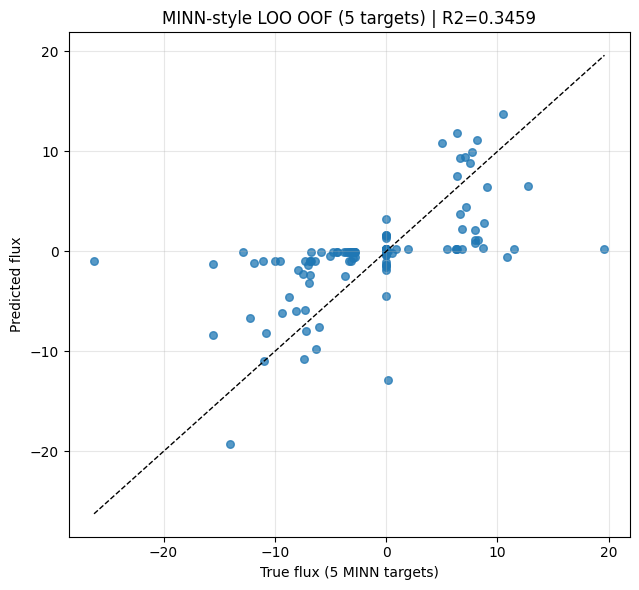

In [31]:
# Train exactly in MINN-repo manner: nested CV
# Outer loop: Leave-One-Out CV
# Inner loop: 5-fold CV hyperparameter search on training split only
# Model specifics here:
# - MLP predicts only 5 channels
# - full transformer input is reconstructed as predicted5 + fixed base_exchanges + zeros

from sklearn.model_selection import LeaveOneOut, KFold

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

set_seed(12345)

# MINN-style CV/HPO settings
minn_cv_seed = 12345
minn_cv_n_fold = 5
minn_cv_max_trials = 25
minn_cv_epochs = 100
minn_cv_batch_size = 5

if device.type == "cuda" and minn_cv_batch_size > 2:
    print("CUDA detected: overriding batch_size 5 -> 2 to avoid OOM with full-output forward.")
    minn_cv_batch_size = 2

search_space = {
    "drop_rate": [0.1, 0.25, 0.5],
    "learning_rate": [0.0002, 0.0005, 0.0007],
    "weight_decay": [0.0, 0.0001, 0.001],
}

# IMPORTANT: run HPO once globally (not once per LOO split) to avoid extremely long runtimes.
MINN_HPO_ONCE = True
# Auxiliary supervision on front-MLP constraints (V0-like outputs):
# total_loss = flux_loss + MINN_CONSTRAINT_AUX_WEIGHT * constraint_loss
MINN_CONSTRAINT_AUX_WEIGHT = 1.0


def _make_model(drop_rate: float, device_obj):
    return FrozenFluxTransformerWithMLP(
        flux_transformer=model,
        input_dim=X_minn_np.shape[1],
        predicted_token_names=minn_target_token_names,
        fixed_base_token_values=fixed_base_token_values,
        hidden_dim=512,
        drop_rate=drop_rate,
    ).to(device_obj)


def _train_eval_split(X_tr_np, y_tr_np, X_va_np, y_va_np, params, epochs, batch_size, device_obj):
    model_local = _make_model(drop_rate=float(params["drop_rate"]), device_obj=device_obj)

    optimizer = torch.optim.AdamW(
        model_local.front_mlp.parameters(),
        lr=float(params["learning_rate"]),
        weight_decay=float(params["weight_decay"]),
    )
    criterion = nn.HuberLoss()

    use_amp = device_obj.type == "cuda"
    amp_device_type = "cuda" if use_amp else device_obj.type
    scaler = torch.amp.GradScaler(amp_device_type, enabled=use_amp)

    X_tr = torch.tensor(X_tr_np, dtype=torch.float32)
    y_tr = torch.tensor(y_tr_np, dtype=torch.float32)
    X_va = torch.tensor(X_va_np, dtype=torch.float32)
    y_va = torch.tensor(y_va_np, dtype=torch.float32)

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, y_tr),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_va, y_va),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )

    target_idx_t = minn_target_indices_t.to(device_obj)
    target_signs_t = minn_target_signs_t.to(device_obj)

    for _epoch in range(epochs):
        model_local.train()
        for xb, yb in train_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb = yb.to(device_obj, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                preds_all_layers, _sel = model_local(xb, output_subset=None)
                preds_last = preds_all_layers[:, :, -1]
                preds_target = preds_last.index_select(1, target_idx_t)

                # Front-MLP constraints are positive magnitudes; recover matching magnitude targets
                # from signed yb using source signs (*_rev columns had sign=-1 during mapping).
                pred_constraints = F.softplus(model_local.front_mlp(xb))
                constraint_targets = torch.clamp(yb * target_signs_t.unsqueeze(0), min=0.0)

                loss_flux = criterion(preds_target, yb)
                loss_constraints = criterion(pred_constraints, constraint_targets)
                loss = loss_flux + float(MINN_CONSTRAINT_AUX_WEIGHT) * loss_constraints

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

    model_local.eval()
    val_loss_sum = 0.0
    val_count = 0
    preds_list = []
    true_list = []
    constraints_list = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb = yb.to(device_obj, non_blocking=True)

            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                preds_all_layers, _sel = model_local(xb, output_subset=None)
                preds_last = preds_all_layers[:, :, -1]
                preds_target = preds_last.index_select(1, target_idx_t)

                pred_constraints = F.softplus(model_local.front_mlp(xb))
                constraint_targets = torch.clamp(yb * target_signs_t.unsqueeze(0), min=0.0)

                val_flux_loss = criterion(preds_target, yb)
                val_constraint_loss = criterion(pred_constraints, constraint_targets)
                val_loss = val_flux_loss + float(MINN_CONSTRAINT_AUX_WEIGHT) * val_constraint_loss

            bs = xb.size(0)
            val_loss_sum += float(val_loss.item()) * bs
            val_count += bs

            preds_list.append(preds_target.detach().cpu().numpy())
            true_list.append(yb.detach().cpu().numpy())

            # Front-MLP predicted 5 constraints (this is what MINN-reservoir passes to pFBA)
            constraints_list.append(pred_constraints.detach().cpu().numpy())

    mean_val_loss = val_loss_sum / max(val_count, 1)
    y_pred = np.concatenate(preds_list, axis=0)
    y_true = np.concatenate(true_list, axis=0)
    y_constraints = np.concatenate(constraints_list, axis=0)

    if device_obj.type == "cuda":
        torch.cuda.empty_cache()

    return mean_val_loss, y_pred, y_true, y_constraints


def _evaluate_params_inner_kfold(X_train_np, y_train_np, params):
    kf = KFold(n_splits=minn_cv_n_fold, shuffle=True, random_state=minn_cv_seed)
    fold_losses = []

    for tr_idx, va_idx in kf.split(X_train_np):
        X_tr, y_tr = X_train_np[tr_idx], y_train_np[tr_idx]
        X_va, y_va = X_train_np[va_idx], y_train_np[va_idx]

        try:
            val_loss, _pred, _true, _c = _train_eval_split(
                X_tr, y_tr, X_va, y_va,
                params=params,
                epochs=minn_cv_epochs,
                batch_size=minn_cv_batch_size,
                device_obj=device,
            )
        except RuntimeError as e:
            if device.type == "cuda" and "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                val_loss, _pred, _true, _c = _train_eval_split(
                    X_tr, y_tr, X_va, y_va,
                    params=params,
                    epochs=minn_cv_epochs,
                    batch_size=1,
                    device_obj=torch.device("cpu"),
                )
            else:
                raise

        fold_losses.append(val_loss)

    return float(np.mean(fold_losses))


def _hpo_on_train_split(X_train_np, y_train_np):
    if OPTUNA_AVAILABLE:
        def objective(trial):
            params = {
                "drop_rate": trial.suggest_categorical("drop_rate", search_space["drop_rate"]),
                "learning_rate": trial.suggest_categorical("learning_rate", search_space["learning_rate"]),
                "weight_decay": trial.suggest_categorical("weight_decay", search_space["weight_decay"]),
            }
            return _evaluate_params_inner_kfold(X_train_np, y_train_np, params)

        sampler = optuna.samplers.TPESampler(seed=minn_cv_seed)
        study = optuna.create_study(direction="minimize", sampler=sampler)
        study.optimize(objective, n_trials=minn_cv_max_trials, n_jobs=1)
        return study.best_params, float(study.best_value)

    best_params = None
    best_score = float("inf")
    for dr in search_space["drop_rate"]:
        for lr in search_space["learning_rate"]:
            for wd in search_space["weight_decay"]:
                params = {"drop_rate": dr, "learning_rate": lr, "weight_decay": wd}
                score = _evaluate_params_inner_kfold(X_train_np, y_train_np, params)
                if score < best_score:
                    best_score = score
                    best_params = params
    return best_params, best_score


loo = LeaveOneOut()

Q2_loo = []
MAE_loo = []
RMSE_loo = []
NE_loo = []
best_params_per_split = []

total_run = X_minn_np.shape[0]
count = 1

oof_true = np.zeros_like(y_minn_np, dtype=np.float32)
oof_pred = np.zeros_like(y_minn_np, dtype=np.float32)
# OOF front-MLP constraints (5) to be used in MINN + pFBA
oof_pred_constraints = np.zeros_like(y_minn_np, dtype=np.float32)

print("MINN-style nested CV training started")
print(f"Outer LOO runs: {total_run}")
print(f"Inner KFold: {minn_cv_n_fold}, trials: {minn_cv_max_trials}, epochs: {minn_cv_epochs}, batch: {minn_cv_batch_size}")
print(f"Constraint aux loss weight: {MINN_CONSTRAINT_AUX_WEIGHT}")
print(f"Optuna available: {OPTUNA_AVAILABLE}")

if MINN_HPO_ONCE:
    print("Running one-time global HPO on full dataset...")
    best_params_global, best_inner_loss_global = _hpo_on_train_split(X_minn_np, y_minn_np)
    print(f"Global best_params: {best_params_global}")
    print(f"Global inner_cv_loss: {best_inner_loss_global:.6f}")

for train_idx, val_idx in loo.split(X_minn_np):
    X_train_np = X_minn_np[train_idx]
    y_train_np = y_minn_np[train_idx]
    X_val_np = X_minn_np[val_idx]
    y_val_np = y_minn_np[val_idx]

    if MINN_HPO_ONCE:
        best_params, best_inner_loss = best_params_global, best_inner_loss_global
    else:
        best_params, best_inner_loss = _hpo_on_train_split(X_train_np, y_train_np)
    best_params_per_split.append(best_params)

    try:
        _val_loss, y_pred_val, y_true_val, y_pred_constraints_val = _train_eval_split(
            X_train_np, y_train_np, X_val_np, y_val_np,
            params=best_params,
            epochs=minn_cv_epochs,
            batch_size=minn_cv_batch_size,
            device_obj=device,
        )
    except RuntimeError as e:
        if device.type == "cuda" and "out of memory" in str(e).lower():
            torch.cuda.empty_cache()
            _val_loss, y_pred_val, y_true_val, y_pred_constraints_val = _train_eval_split(
                X_train_np, y_train_np, X_val_np, y_val_np,
                params=best_params,
                epochs=minn_cv_epochs,
                batch_size=1,
                device_obj=torch.device("cpu"),
            )
        else:
            raise

    i = int(val_idx[0])
    oof_true[i] = y_true_val[0]
    oof_pred[i] = y_pred_val[0]
    oof_pred_constraints[i] = y_pred_constraints_val[0]

    q2_value = r2_score(y_true_val.flatten(), y_pred_val.flatten())
    mae_value = float(np.mean(np.abs(y_true_val - y_pred_val)))
    rmse_value = float(np.sqrt(np.mean((y_true_val - y_pred_val) ** 2)))
    ne_value = float(np.nan_to_num(np.linalg.norm(y_true_val - y_pred_val) / np.linalg.norm(y_true_val), posinf=0, neginf=0, nan=0))

    Q2_loo.append(q2_value)
    MAE_loo.append(mae_value)
    RMSE_loo.append(rmse_value)
    NE_loo.append(ne_value)

    print(f"run {count}/{total_run}")
    print(f"  best_params: {best_params}")
    print(f"  inner_cv_loss: {best_inner_loss:.6f}")
    print(f"  Q2: {q2_value:.6f} | MAE: {mae_value:.6f} | RMSE: {rmse_value:.6f} | NE: {ne_value:.6f}")

    count += 1

r2_oof = r2_score(oof_true.ravel(), oof_pred.ravel())
mae_oof = mean_absolute_error(oof_true.ravel(), oof_pred.ravel())
rmse_oof = root_mean_squared_error(oof_true.ravel(), oof_pred.ravel())

print("=== MINN-style nested CV summary ===")
print(f"LOO mean Q2:   {np.mean(Q2_loo):.6f} +/- {np.std(Q2_loo, ddof=1):.6f}")
print(f"LOO mean MAE:  {np.mean(MAE_loo):.6f} +/- {np.std(MAE_loo, ddof=1):.6f}")
print(f"LOO mean RMSE: {np.mean(RMSE_loo):.6f} +/- {np.std(RMSE_loo, ddof=1):.6f}")
print(f"LOO mean NE:   {np.mean(NE_loo):.6f} +/- {np.std(NE_loo, ddof=1):.6f}")
print(f"Pooled OOF R2:   {r2_oof:.6f}")
print(f"Pooled OOF MAE:  {mae_oof:.6f}")
print(f"Pooled OOF RMSE: {rmse_oof:.6f}")

# Diagnostic prints for split->unsplit sign handling and front-MLP constraint quality.
target_magnitudes = np.maximum(0.0, oof_true * minn_target_signs.reshape(1, -1))
pred_magnitudes = np.maximum(0.0, oof_pred_constraints)
print("\nConstraint diagnostics (target magnitude vs front-MLP prediction)")
for j, (src, tok, idx, sign) in enumerate(minn_mapped_sources):
    t_med = float(np.median(target_magnitudes[:, j]))
    p_med = float(np.median(pred_magnitudes[:, j]))
    t_mean = float(np.mean(target_magnitudes[:, j]))
    p_mean = float(np.mean(pred_magnitudes[:, j]))
    print(
        f"  {src:>18} (sign={sign:+.0f}) | "
        f"target med/mean={t_med:.6f}/{t_mean:.6f} | "
        f"pred med/mean={p_med:.6f}/{p_mean:.6f}"
    )

plt.figure(figsize=(6.5, 6.0))
plt.scatter(oof_true.ravel(), oof_pred.ravel(), alpha=0.75, s=30)
xy_min = float(min(oof_true.min(), oof_pred.min()))
xy_max = float(max(oof_true.max(), oof_pred.max()))
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'k--', lw=1)
plt.xlabel("True flux (5 MINN targets)")
plt.ylabel("Predicted flux")
plt.title(f"MINN-style LOO OOF (5 targets) | R2={r2_oof:.4f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Baseline pFBA

After training the front MLP, the next step is to compute a **baseline pFBA** using only measured glucose and oxygen uptake as inputs (no MINN-added constraints yet).
We then evaluate pFBA with the same paper-style metrics (Q2, MAE, RMSE, NE) as mean and standard deviation across samples.


In [32]:
# Baseline pFBA (paper-style metrics), without MINN + pFBA
# Uses ONLY measured glucose and oxygen uptake as inputs.

from pathlib import Path

try:
    from cobra.io import read_sbml_model
    from cobra.flux_analysis import pfba as cobra_pfba
except Exception as e:
    raise ImportError(
        "cobra is required for pFBA baseline evaluation. Install cobra in the notebook environment."
    ) from e

fluxomics_path = Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE
if not fluxomics_path.exists():
    raise FileNotFoundError(f"Fluxomics file not found: {fluxomics_path}")

flux_df = pd.read_csv(fluxomics_path)

# Paper-style evaluation flux set: all measured fluxomics columns (exclude experiment id).
metric_source_cols = [c for c in flux_df.columns if c != "experiment"]

# Map MINN split-naming columns into iML1515 FluxTransformer token naming (+ sign conversion).
mapped_metrics = []  # (source_col, token_name, sign)
for src in metric_source_cols:
    tok, sign = _minn_to_flux_token(src, outputs)
    if tok is not None:
        mapped_metrics.append((src, tok, float(sign)))

if not mapped_metrics:
    raise RuntimeError("No metric flux columns could be mapped to iML1515 token space.")

metric_map_df = pd.DataFrame(mapped_metrics, columns=["source_flux", "mapped_token", "sign_to_iML1515"])

# Need these two baseline inputs from measured data.
for c in MINN_INPUT_FLUX_COLS:
    if c not in flux_df.columns:
        raise ValueError(f"Required pFBA input column missing in fluxomics file: {c}")

model_path = Path("./models/iML1515.xml")
if not model_path.exists():
    raise FileNotFoundError(f"SBML model not found: {model_path}")

base_cobra_model = read_sbml_model(str(model_path))

def _metric_row(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    # Same spirit as MINN paper implementation: per-sample r^2 across fluxes.
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        q2 = 0.0
    else:
        r = np.corrcoef(y_true, y_pred)[0, 1]
        q2 = 0.0 if np.isnan(r) else float(r * r)

    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
    return q2, mae, rmse, ne

pred_rows = []
metric_rows = []
failed_samples = []

for _, row in flux_df.iterrows():
    exp_name = row["experiment"]

    # Baseline pFBA: only measured glucose and oxygen uptake are injected.
    glc_uptake = float(row["R_EX_glc__D_e_rev"])  # positive uptake magnitude in MINN split data
    o2_uptake = float(row["R_EX_o2_e_rev"])

    m = base_cobra_model.copy()
    try:
        m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake
        m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake
    except KeyError as e:
        raise KeyError("Expected EX_glc__D_e and EX_o2_e reactions in iML1515 model.") from e

    try:
        sol = cobra_pfba(m)
        sol_status = getattr(sol, "status", "optimal")
        if sol_status != "optimal":
            raise RuntimeError(f"pFBA status={sol_status}")
    except Exception as e:
        failed_samples.append((exp_name, str(e)))
        continue

    y_true = []
    y_pred = []
    pred_row = {"experiment": exp_name}

    for src, tok, sign in mapped_metrics:
        rxn_id = tok[:-5] if tok.endswith("_flux") else tok
        pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign
        true_val = float(row[src])

        y_true.append(true_val)
        y_pred.append(pred_val)
        pred_row[src] = pred_val

    q2, mae, rmse, ne = _metric_row(y_true, y_pred)
    metric_rows.append({
        "experiment": exp_name,
        "Q2": q2,
        "MAE": mae,
        "RMSE": rmse,
        "NE": ne,
    })
    pred_rows.append(pred_row)

pfba_baseline_pred_df = pd.DataFrame(pred_rows)
pfba_baseline_metrics_per_sample_df = pd.DataFrame(metric_rows)

if pfba_baseline_metrics_per_sample_df.empty:
    raise RuntimeError("No successful pFBA samples. Check model feasibility and constraints.")

# Paper-style summary: mean +/- std across samples (population std, like np.std default).
pfba_baseline_summary_df = pd.DataFrame({
    "avg": [
        float(pfba_baseline_metrics_per_sample_df["Q2"].mean()),
        float(pfba_baseline_metrics_per_sample_df["MAE"].mean()),
        float(pfba_baseline_metrics_per_sample_df["RMSE"].mean()),
        float(pfba_baseline_metrics_per_sample_df["NE"].mean()),
    ],
    "std": [
        float(pfba_baseline_metrics_per_sample_df["Q2"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["MAE"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["RMSE"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["NE"].std(ddof=0)),
    ],
}, index=["Q2", "MAE", "RMSE", "NE"])

print("=== Baseline pFBA summary (without MINN + pFBA) ===")
print(f"Samples evaluated: {len(pfba_baseline_metrics_per_sample_df)}/{len(flux_df)}")
print(f"Metric fluxes mapped: {len(mapped_metrics)} / {len(metric_source_cols)}")
if failed_samples:
    print(f"Failed samples: {len(failed_samples)}")
    for exp_name, msg in failed_samples[:5]:
        print(f"  - {exp_name}: {msg}")

display(pfba_baseline_summary_df)
display(metric_map_df.head(10))



=== Baseline pFBA summary (without MINN + pFBA) ===
Samples evaluated: 29/29
Metric fluxes mapped: 47 / 47


,avg,std
Q2,0.893020,0.132210
MAE,0.498357,0.365259
RMSE,0.833339,0.633606
NE,0.309672,0.373233


,source_flux,mapped_token,sign_to_iML1515
0,R_GLCptspp,GLCptspp_flux,1.0
1,R_PGI_fwd,PGI_flux,1.0
2,R_PFK,PFK_flux,1.0
3,R_FBA_fwd,FBA_flux,1.0
4,R_TPI_fwd,TPI_flux,1.0
5,R_PGK_rev,PGK_flux,-1.0
6,R_GAPD_fwd,GAPD_flux,1.0
7,R_ENO_fwd,ENO_flux,1.0
8,R_PGM_rev,PGM_flux,-1.0
9,R_PYK,PYK_flux,1.0


### MINN + pFBA

This step runs pFBA with **measured glucose/oxygen uptake** plus **MINN-predicted ethanol/acetate constraints** (MINN-style comparison setup).
Metrics are computed exactly as for baseline pFBA (Q2, MAE, RMSE, NE; mean and std across samples).


In [37]:
# MINN + pFBA (paper-style comparison against baseline pFBA)
# Uses 5 front-MLP OOF predicted constraints as pFBA inputs.

from pathlib import Path

if "oof_pred_constraints" not in globals():
    raise RuntimeError("OOF front-MLP constraints not found. Run rc_minn_train first.")

# Rebuild experiment order exactly as load_minn_omics_for_reservoir to align with oof_pred_constraints rows.
tr_df = pd.read_csv(Path(MINN_DATA_DIR) / "transcriptomics.csv")
pr_df = pd.read_csv(Path(MINN_DATA_DIR) / "proteomics.csv")
fl_df = pd.read_csv(Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE)

x_df_tmp = tr_df.merge(pr_df, on="experiment", how="left")
x_df_tmp = x_df_tmp.merge(fl_df[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
x_df_tmp = x_df_tmp[x_df_tmp["experiment"].isin(fl_df["experiment"])].reset_index(drop=True)
exp_order_oof = x_df_tmp["experiment"].tolist()

if len(exp_order_oof) != oof_pred_constraints.shape[0]:
    raise RuntimeError(
        f"Experiment/OOF length mismatch: {len(exp_order_oof)} vs {oof_pred_constraints.shape[0]}."
    )

# Column positions in oof_pred_constraints follow MINN_PREDICTED_5_SOURCE order.
src_to_idx = {s: i for i, s in enumerate(MINN_PREDICTED_5_SOURCE)}
needed_sources = [
    "R_EX_glc__D_e_rev",
    "R_EX_o2_e_rev",
    "R_EX_co2_e_fwd",
    "R_EX_etoh_e",
    "R_EX_ac_e",
]
for s in needed_sources:
    if s not in src_to_idx:
        raise ValueError(f"Missing expected predicted source in MINN_PREDICTED_5_SOURCE: {s}")

pred_vin_df = pd.DataFrame({
    "experiment": exp_order_oof,
    "R_EX_glc__D_e_rev_pred": np.maximum(0.0, oof_pred_constraints[:, src_to_idx["R_EX_glc__D_e_rev"]]),
    "R_EX_o2_e_rev_pred": np.maximum(0.0, oof_pred_constraints[:, src_to_idx["R_EX_o2_e_rev"]]),
    "R_EX_co2_e_fwd_pred": np.maximum(0.0, oof_pred_constraints[:, src_to_idx["R_EX_co2_e_fwd"]]),
    "R_EX_etoh_e_pred": np.maximum(0.0, oof_pred_constraints[:, src_to_idx["R_EX_etoh_e"]]),
    "R_EX_ac_e_pred": np.maximum(0.0, oof_pred_constraints[:, src_to_idx["R_EX_ac_e"]]),
})

# Join measured fluxomics + predicted 5 constraints
flux_df_eval = fl_df.merge(pred_vin_df, on="experiment", how="inner")
if flux_df_eval.empty:
    raise RuntimeError("Empty merged dataframe for MINN + pFBA evaluation.")

# Reuse mapped metric set from baseline cell if available; otherwise rebuild mapping.
if "mapped_metrics" not in globals() or not mapped_metrics:
    metric_source_cols = [c for c in fl_df.columns if c != "experiment"]
    mapped_metrics = []
    for src in metric_source_cols:
        tok, sign = _minn_to_flux_token(src, outputs)
        if tok is not None:
            mapped_metrics.append((src, tok, float(sign)))

if not mapped_metrics:
    raise RuntimeError("No mapped metrics available for MINN + pFBA evaluation.")

# Ensure baseline metric function exists
if "_metric_row" not in globals():
    def _metric_row(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=np.float64)
        y_pred = np.asarray(y_pred, dtype=np.float64)
        if np.std(y_true) == 0 or np.std(y_pred) == 0:
            q2 = 0.0
        else:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            q2 = 0.0 if np.isnan(r) else float(r * r)
        mae = float(np.mean(np.abs(y_true - y_pred)))
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
        return q2, mae, rmse, ne

pred_rows_minn_pfba = []
metric_rows_minn_pfba = []
failed_samples_minn_pfba = []

for _, row in flux_df_eval.iterrows():
    exp_name = row["experiment"]

    # MINN-style pFBA: keep measured glucose/oxygen, add predicted ethanol/acetate
    glc_uptake_meas = float(row["R_EX_glc__D_e_rev"])
    o2_uptake_meas = float(row["R_EX_o2_e_rev"])
    etoh_pred = float(row["R_EX_etoh_e_pred"])
    ac_pred = float(row["R_EX_ac_e_pred"])

    m = base_cobra_model.copy()
    try:
        # measured uptake magnitudes -> lower bounds (negative)
        m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake_meas
        m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake_meas

        # add MINN-predicted extra exchanges as uptake-style lower bounds (negative)
        m.reactions.get_by_id("EX_etoh_e").lower_bound = -etoh_pred
        m.reactions.get_by_id("EX_ac_e").lower_bound = -ac_pred
    except KeyError as e:
        raise KeyError("Expected EX_glc__D_e, EX_o2_e, EX_co2_e, EX_etoh_e, EX_ac_e in iML1515 model.") from e

    try:
        sol = cobra_pfba(m)
        sol_status = getattr(sol, "status", "optimal")
        if sol_status != "optimal":
            raise RuntimeError(f"pFBA status={sol_status}")
    except Exception as e:
        failed_samples_minn_pfba.append((exp_name, str(e)))
        continue

    y_true = []
    y_pred = []
    pred_row = {"experiment": exp_name}
    for src, tok, sign in mapped_metrics:
        rxn_id = tok[:-5] if tok.endswith("_flux") else tok
        pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign
        true_val = float(row[src])
        y_true.append(true_val)
        y_pred.append(pred_val)
        pred_row[src] = pred_val

    q2, mae, rmse, ne = _metric_row(y_true, y_pred)
    metric_rows_minn_pfba.append({
        "experiment": exp_name,
        "Q2": q2,
        "MAE": mae,
        "RMSE": rmse,
        "NE": ne,
    })
    pred_rows_minn_pfba.append(pred_row)

minn_pfba_pred_df = pd.DataFrame(pred_rows_minn_pfba)
minn_pfba_metrics_per_sample_df = pd.DataFrame(metric_rows_minn_pfba)

if minn_pfba_metrics_per_sample_df.empty:
    raise RuntimeError("No successful MINN + pFBA samples. Check constraint feasibility.")

minn_pfba_summary_df = pd.DataFrame({
    "avg": [
        float(minn_pfba_metrics_per_sample_df["Q2"].mean()),
        float(minn_pfba_metrics_per_sample_df["MAE"].mean()),
        float(minn_pfba_metrics_per_sample_df["RMSE"].mean()),
        float(minn_pfba_metrics_per_sample_df["NE"].mean()),
    ],
    "std": [
        float(minn_pfba_metrics_per_sample_df["Q2"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["MAE"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["RMSE"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["NE"].std(ddof=0)),
    ],
}, index=["Q2", "MAE", "RMSE", "NE"])

print("=== MINN + pFBA summary ===")
print(f"Samples evaluated: {len(minn_pfba_metrics_per_sample_df)}/{len(flux_df_eval)}")
if failed_samples_minn_pfba:
    print(f"Failed samples: {len(failed_samples_minn_pfba)}")
    for exp_name, msg in failed_samples_minn_pfba[:5]:
        print(f"  - {exp_name}: {msg}")

display(minn_pfba_summary_df)
display(pred_vin_df.head(10))

if "pfba_baseline_summary_df" in globals():
    comparison_df = pd.concat(
        {"pFBA": pfba_baseline_summary_df["avg"], "MINN + pFBA": minn_pfba_summary_df["avg"]},
        axis=1
    )
    print("=== Average metric comparison ===")
    display(comparison_df)


=== MINN + pFBA summary ===
Samples evaluated: 29/29


,avg,std
Q2,0.791189,0.253372
MAE,0.857416,0.798601
RMSE,1.428159,1.427928
NE,0.471588,0.476270


,experiment,R_EX_glc__D_e_rev_pred,R_EX_o2_e_rev_pred,R_EX_co2_e_fwd_pred,R_EX_etoh_e_pred,R_EX_ac_e_pred
0,REF,1.395354e-07,1.224582e+01,6.418059e+01,6.548381e-10,6.530592e+01
1,WT_0.1h-1,1.129824e-17,3.178440e-09,9.532700e+00,4.538229e-08,9.151321e-10
2,WT_0.4h-1,2.047831e-06,8.249559e+00,1.100484e-09,4.212963e+01,2.326073e+01
3,WT_0.5h-1,4.972874e-08,2.598368e+01,4.395458e+00,1.444102e+01,7.081247e-05
4,WT_0.7h-1,1.083528e-04,3.360812e-08,1.074938e+01,3.652042e-11,3.412619e-11
5,galM,3.934369e-02,8.874334e+00,5.888699e+01,2.904405e-08,4.941413e+01
6,glk,9.324639e-01,1.263975e+01,1.319690e-08,1.363569e-09,4.751997e-04
7,pgm,3.149569e-02,2.488138e+01,3.931824e-07,4.438746e-11,1.048888e-04
8,pgi,7.623069e-12,6.349622e-17,1.322715e+01,2.120329e-16,4.828443e-11
9,pfkA,1.573914e-08,4.883265e-14,1.041902e+01,4.198454e-13,6.828312e-08


=== Average metric comparison ===


,pFBA,MINN + pFBA
Q2,0.893020,0.791189
MAE,0.498357,0.857416
RMSE,0.833339,1.428159
NE,0.309672,0.471588


5 front-MLP predicted fluxes: constraint stats + OOF metrics


,flux,vocab_idx,pre_transformer_mean,pre_transformer_std,pre_transformer_min,pre_transformer_max,oof_r2,oof_mae,oof_rmse
0,EX_glc__D_e_flux,180,0.003534,0.006265,9.593352e-05,0.032592,-3.567306,3.636220,4.176467
1,EX_o2_e_flux,1981,0.000053,0.000183,9.806402e-11,0.000959,-2.423798,5.978955,7.647532
2,EX_co2_e_flux,45,1.904561,1.050286,9.049461e-01,5.235280,-3.687484,5.523342,6.665419
3,EX_etoh_e_flux,1525,2.566466,2.161190,4.124890e-04,6.829520,-4623.962402,0.622342,2.486455
4,EX_ac_e_flux,106,0.001416,0.006617,4.790135e-08,0.035636,-10.786855,0.820952,1.239440


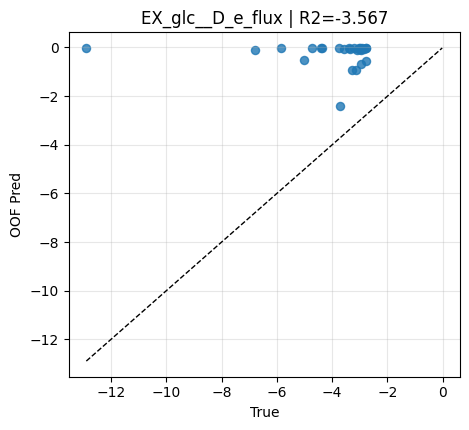

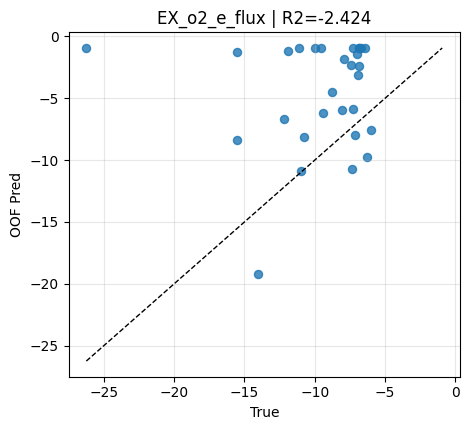

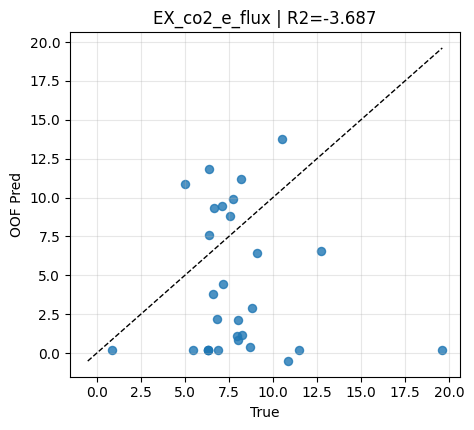

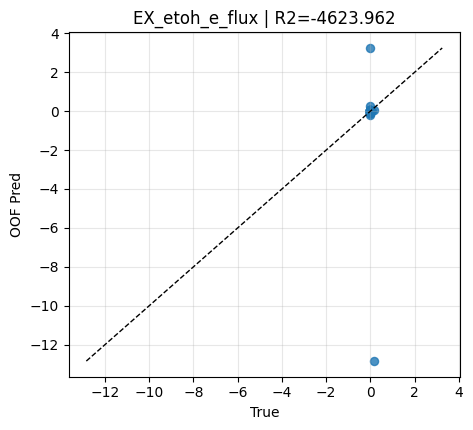

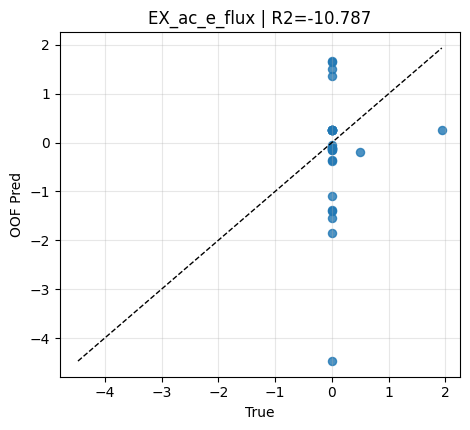

In [38]:
# Investigate the 5 fluxes predicted by the front MLP in a dedicated cell
# - pre_transformer_constraints: c0 channels before FluxTransformer
# - OOF metrics/scatter from nested CV run

inspect_fluxes = list(minn_target_token_names)

if len(inspect_fluxes) != 5:
    raise ValueError(f"Expected exactly 5 predicted fluxes, got {len(inspect_fluxes)}: {inspect_fluxes}")

# indices in vocabulary
token_to_idx = {tok: i for i, tok in enumerate(outputs)}
inspect_indices = [token_to_idx[f] for f in inspect_fluxes]

# Build c0 for all samples
X_all_t = torch.tensor(X_minn_np, dtype=torch.float32, device=device)
minn_model.eval()
with torch.no_grad():
    c0_all = minn_model.build_full_input_vector(X_all_t).detach().cpu().numpy()  # [N, vocab]

# summary
rows = []
for flux, idx in zip(inspect_fluxes, inspect_indices):
    cvals = c0_all[:, idx]
    col = inspect_fluxes.index(flux)

    row = {
        "flux": flux,
        "vocab_idx": idx,
        "pre_transformer_mean": float(np.mean(cvals)),
        "pre_transformer_std": float(np.std(cvals, ddof=1)) if len(cvals) > 1 else 0.0,
        "pre_transformer_min": float(np.min(cvals)),
        "pre_transformer_max": float(np.max(cvals)),
        "oof_r2": float(r2_score(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
        "oof_mae": float(mean_absolute_error(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
        "oof_rmse": float(root_mean_squared_error(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
    }
    rows.append(row)

inspect_df = pd.DataFrame(rows)
print("5 front-MLP predicted fluxes: constraint stats + OOF metrics")
display(inspect_df)

# one scatter per flux
if 'oof_true' in globals() and 'oof_pred' in globals():
    for i, flux in enumerate(inspect_fluxes):
        y_t = oof_true[:, i]
        y_p = oof_pred[:, i]
        r2_val = r2_score(y_t, y_p)

        plt.figure(figsize=(4.8, 4.4))
        plt.scatter(y_t, y_p, alpha=0.8, s=34)
        lo = float(min(y_t.min(), y_p.min()))
        hi = float(max(y_t.max(), y_p.max()))
        plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
        plt.xlabel("True")
        plt.ylabel("OOF Pred")
        plt.title(f"{flux} | R2={r2_val:.3f}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("Run the nested CV training cell first to generate OOF outputs.")
